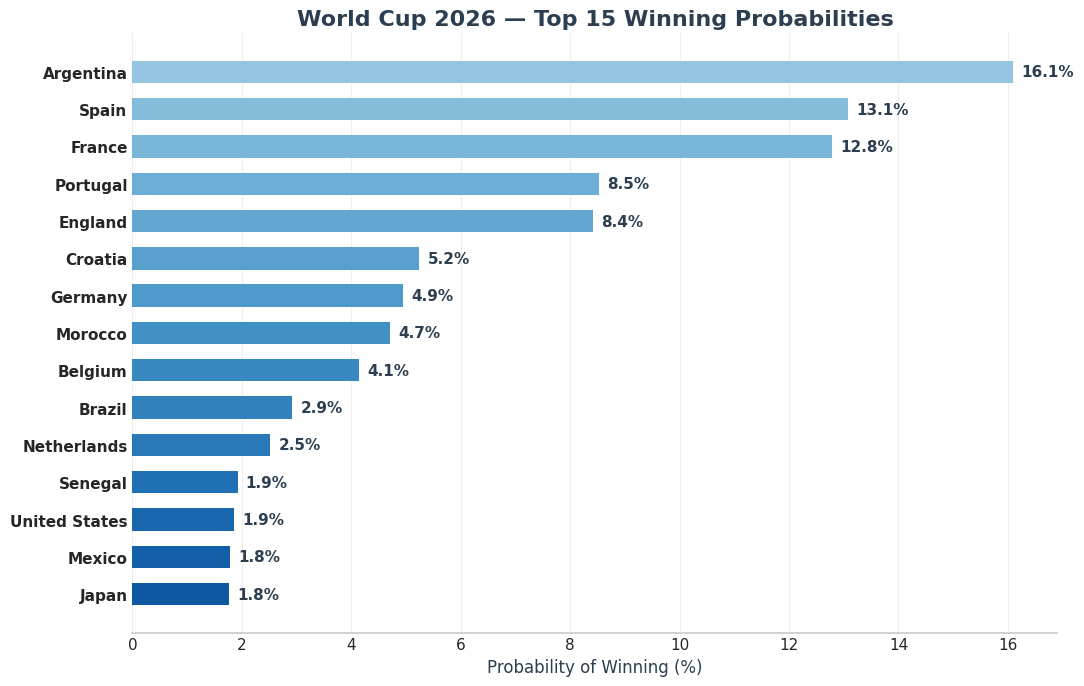

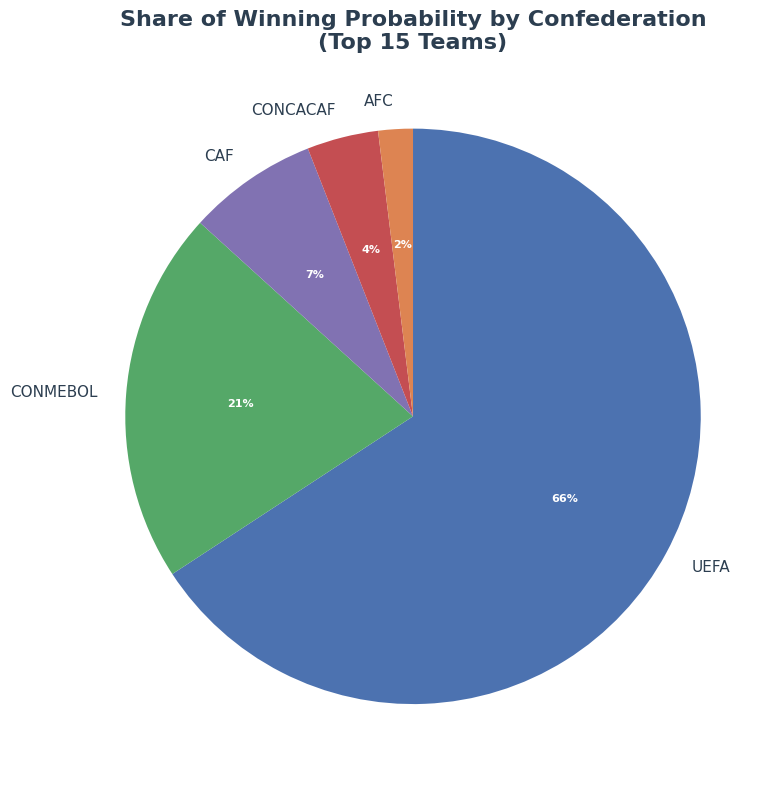

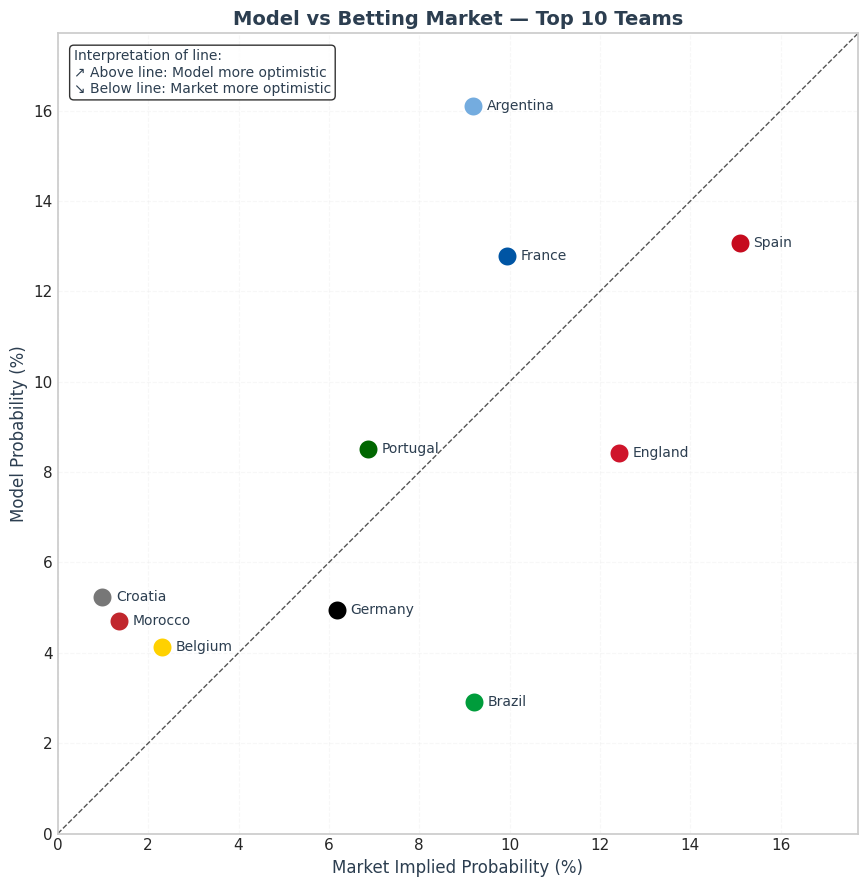

In [17]:
# =============================================================================
# WORLD CUP 2026 — CLEAN & PROFESSIONAL VISUALS
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


# =============================================================================
# GLOBAL STYLE
# =============================================================================

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CCCCCC",
    "axes.labelcolor": "#2c3e50",
    "text.color": "#2c3e50",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "grid.color": "#E5E5E5",
    "grid.linestyle": "-",
    "grid.alpha": 0.6
})

# =============================================================================
# LOAD DATA
# =============================================================================

results = pd.read_csv("../simulation_results/world_cup_2026_winner_probabilities.csv")
results = results.sort_values("probability_percent", ascending=False)

fifa_ranking = pd.read_csv("../data/processed/fifa_latest_world_ranking.csv")
bookmakers = pd.read_csv("../data/processed/world_cup_2026_bookmaker_odds.csv")

# =============================================================================
# GRAPH 1 — TOP 15 WINNER PROBABILITIES
# =============================================================================

TOP_N = 15
top = results.head(TOP_N)

fig, ax = plt.subplots(figsize=(11, 7))

y = np.arange(len(top))
colors = plt.cm.Blues(np.linspace(0.4, 0.85, TOP_N))

ax.barh(y, top["probability_percent"], color=colors, height=0.6)

ax.set_yticks(y)
ax.set_yticklabels(top["team"], fontweight="bold")
ax.invert_yaxis()

for i, val in enumerate(top["probability_percent"]):
    ax.text(val + 0.15, i, f"{val:.1f}%", va="center", fontweight="bold")

ax.set_xlabel("Probability of Winning (%)")
ax.set_title("World Cup 2026 — Top 15 Winning Probabilities")

ax.grid(axis="x")
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

# =============================================================================
# GRAPH 2 — CONFEDERATION SHARE (PIE, REFINED LABELS)
# =============================================================================

top_conf = top.merge(
    fifa_ranking[["country", "conf"]],
    left_on="team",
    right_on="country",
    how="left"
)

conf_dist = (
    top_conf
    .groupby("conf", as_index=False)
    .agg(total_prob=("probability_percent", "sum"))
    .sort_values("total_prob", ascending=False)
)

conf_colors = {
    "UEFA": "#4C72B0",
    "CONMEBOL": "#55A868",
    "CONCACAF": "#C44E52",
    "AFC": "#DD8452",
    "CAF": "#8172B2",
    "OFC": "#64B5CD"
}

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    conf_dist["total_prob"],
    labels=conf_dist["conf"],
    autopct="%1.0f%%",
    startangle=90,
    counterclock=False,
    colors=[conf_colors.get(c, "#999999") for c in conf_dist["conf"]],
    textprops={"fontsize": 11}
)

for a in autotexts:
    a.set_fontsize(8)
    a.set_color("white")
    a.set_fontweight("bold")

ax.set_title("Share of Winning Probability by Confederation\n(Top 15 Teams)")

plt.tight_layout()
plt.show()

# =============================================================================
# GRAPH 3 — MODEL VS MARKET (TOP 10, BY COUNTRY)
# =============================================================================

TOP_N_COMPARE = 10

compare = (
    results
    .merge(bookmakers, on="team", how="inner")
    .head(TOP_N_COMPARE)
)

# Diccionario de colores representativos por país (aprox. color principal de la bandera)
country_colors = {
    "Spain": "#C60B1E",
    "Argentina": "#74ACDF",
    "France": "#0055A4",
    "England": "#CF142B",
    "Brazil": "#009C3B",
    "Portugal": "#006600",
    "Netherlands": "#21468B",
    "Morocco": "#C1272D",
    "Belgium": "#FFD100",
    "Germany": "#000000",
}

fig, ax = plt.subplots(figsize=(9,9))

max_val = max(compare["implied_norm_probability"].max(), compare["probability_percent"].max()) * 1.1

# Línea de igualdad
ax.plot([0, max_val], [0, max_val], "--", color="#555555", linewidth=1, label="Modelo = Mercado")

# Scatter con color por país
for idx, row in compare.iterrows():
    x = row["implied_norm_probability"]
    y = row["probability_percent"]
    color = country_colors.get(row["team"], "#777777")
    ax.scatter(x, y, s=200, color=color, edgecolors="white", linewidth=1.2, zorder=5)
    ax.text(x + 0.3, y, row["team"], fontsize=10, va="center")

# Ejes y aspecto
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect("equal")
ax.set_xlabel("Market Implied Probability (%)", fontsize=12)
ax.set_ylabel("Model Probability (%)", fontsize=12)
ax.set_title("Model vs Betting Market — Top 10 Teams", fontsize=14, fontweight="bold")

# Grid
ax.grid(True, alpha=0.3, linestyle="--")

# Leyenda de interpretación
legend_text = ("Interpretation of line:\n"
               "↗ Above line: Model more optimistic\n"
               "↘ Below line: Market more optimistic")
ax.text(0.02, 0.98, legend_text, transform=ax.transAxes, fontsize=10,
        va="top", ha="left", bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.3"))

plt.tight_layout()
plt.show()